# Fraud Detection in Internship Applications
**Internee.pk Data Analytics Internship — Task 4 (Major Project)**

This notebook identifies anomalies in internship applications so that fake or
manipulated entries can be caught before they reach the review stage. It looks
for three kinds of suspicious behaviour: duplicate/near-duplicate entries,
rapid or bot-like submission bursts, and internally inconsistent data
(impossible GPA, age, or graduation year). Isolation Forest and K-Means are
then used to catch anomalies that don't fit a fixed rule, and the two models
are combined into a single alert system.

No dataset was provided for this task, so a synthetic dataset of internship
applications was generated, with a known set of fraud patterns deliberately
injected so the detection methods could be evaluated against ground truth.

## 1. Generating the application dataset
Creates ~1,100 applications: ~950 genuine ones plus three injected fraud patterns — duplicate identities, rapid bot-style submission bursts, and internally inconsistent records.

In [1]:
"""
Generates a synthetic internship-application dataset for the fraud-detection task.
Ground-truth fraud labels are kept aside (ground_truth_fraud) purely so the
unsupervised models can be evaluated afterwards - they are NOT used as a model input.
"""

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

random.seed(42)
np.random.seed(42)

FIRST_NAMES = ["Ahmed","Ali","Sara","Ayesha","Hassan","Fatima","Bilal","Zainab","Usman",
               "Mariam","Hamza","Sana","Omar","Iqra","Farah","Danish","Noor","Saad",
               "Hina","Talha","Rida","Faizan","Amna","Shahzaib","Laiba","Zohaib","Mahnoor",
               "Kashif","Sadia","Waleed","Momina","Arslan","Kiran","Shayan","Anum","Yasir",
               "Nida","Fahad","Asma","Tayyab","Uzma","Rayyan","Sidra","Junaid","Areeba",
               "Salman","Maha","Ibrahim","Komal","Adeel"]
LAST_NAMES = ["Khan","Ahmed","Siddiqui","Malik","Raza","Sheikh","Baig","Farooq","Qureshi",
              "Iqbal","Hussain","Javed","Rehman","Aslam","Chaudhry","Abbasi","Soomro",
              "Bhatti","Gill","Niazi","Awan","Dar","Butt","Mughal","Khalid","Anwar",
              "Yousaf","Saleem","Riaz","Nawaz"]
UNIVERSITIES = ["Virtual University of Pakistan","NUST","LUMS","FAST-NUCES","COMSATS",
                "UET Lahore","Karachi University","Punjab University","IBA Karachi","Bahria University"]
DEPARTMENTS = ["Data Science","Software Engineering","Marketing","Finance","HR","Graphic Design"]

N_LEGIT = 950
BASE_TIME = datetime(2026, 8, 1, 8, 0, 0)


def random_time(days_span=45):
    return BASE_TIME + timedelta(
        days=random.uniform(0, days_span),
        hours=random.uniform(0, 14),  # applications mostly submitted 8am-10pm
    )


def make_name():
    return f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}"


def make_email(name, salt=""):
    handle = name.lower().replace(" ", ".") + salt
    domain = random.choice(["gmail.com", "yahoo.com", "outlook.com", "hotmail.com"])
    return f"{handle}{random.randint(1,999) if salt=='' else ''}@{domain}"


def make_phone():
    return f"03{random.randint(0,9)}{random.randint(1000000,9999999)}"


def make_ip():
    return f"{random.randint(1,223)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}"


rows = []

# ---------- 1. Legitimate applications ----------
for i in range(N_LEGIT):
    name = make_name()
    gpa = round(np.clip(np.random.normal(3.1, 0.4), 2.0, 4.0), 2)
    age = int(np.clip(np.random.normal(22, 2), 19, 30))
    grad_year = 2026 - int(np.clip(np.random.normal(1, 1), 0, 5))
    rows.append({
        "applicant_id": f"APP{i:05d}",
        "name": name,
        "email": make_email(name),
        "phone": make_phone(),
        "ip_address": make_ip(),
        "university": random.choice(UNIVERSITIES),
        "department_applied": random.choice(DEPARTMENTS),
        "gpa": gpa,
        "age": age,
        "graduation_year": grad_year,
        "cover_letter_length": int(np.clip(np.random.normal(180, 60), 40, 500)),
        "submission_time": random_time(),
        "ground_truth_fraud": 0,
        "fraud_type": "none",
    })

# ---------- 2. Duplicate / multi-account fraud ----------
# same person re-applying with slightly altered name/email to farm rewards
for i in range(25):
    base = random.choice(rows[:N_LEGIT])
    n_dupes = random.randint(2, 4)
    shared_ip = make_ip()
    burst_start = random_time()
    for d in range(n_dupes):
        rows.append({
            "applicant_id": f"DUP{i:03d}{d}",
            "name": base["name"] if d == 0 else base["name"] + random.choice(["", " "]),
            "email": base["email"] if d == 0 else make_email(base["name"], salt=str(d)),
            "phone": base["phone"] if random.random() < 0.7 else make_phone(),
            "ip_address": shared_ip,
            "university": base["university"],
            "department_applied": base["department_applied"],
            "gpa": base["gpa"],
            "age": base["age"],
            "graduation_year": base["graduation_year"],
            "cover_letter_length": base["cover_letter_length"] + random.randint(-5, 5),
            "submission_time": burst_start + timedelta(minutes=random.uniform(1, 20)),
            "ground_truth_fraud": 1,
            "fraud_type": "duplicate_identity",
        })

# ---------- 3. Rapid / bot-like submissions ----------
# many applications from the same IP within a very short window
for batch in range(8):
    shared_ip = make_ip()
    burst_start = random_time()
    n_burst = random.randint(6, 12)
    for j in range(n_burst):
        name = make_name()
        rows.append({
            "applicant_id": f"BOT{batch:02d}{j:02d}",
            "name": name,
            "email": make_email(name, salt=str(j)),
            "phone": make_phone(),
            "ip_address": shared_ip,
            "university": random.choice(UNIVERSITIES),
            "department_applied": random.choice(DEPARTMENTS),
            "gpa": round(random.uniform(2.0, 4.0), 2),
            "age": random.randint(19, 30),
            "graduation_year": random.randint(2022, 2027),
            "cover_letter_length": random.randint(15, 40),  # very short, generic
            "submission_time": burst_start + timedelta(seconds=random.uniform(5, 90)),
            "ground_truth_fraud": 1,
            "fraud_type": "rapid_bot_submission",
        })

# ---------- 4. Inconsistent / implausible data ----------
for i in range(30):
    name = make_name()
    grad_year = random.choice([2018, 2029, 2030])  # implausible (too old / future)
    age = random.choice([16, 17, 55, 60])           # implausible age for internship
    gpa = random.choice([4.8, 5.0, -1.0, 0.1])       # out-of-range GPA
    rows.append({
        "applicant_id": f"INC{i:03d}",
        "name": name,
        "email": make_email(name),
        "phone": make_phone(),
        "ip_address": make_ip(),
        "university": random.choice(UNIVERSITIES),
        "department_applied": random.choice(DEPARTMENTS),
        "gpa": gpa,
        "age": age,
        "graduation_year": grad_year,
        "cover_letter_length": int(np.clip(np.random.normal(180, 60), 40, 500)),
        "submission_time": random_time(),
        "ground_truth_fraud": 1,
        "fraud_type": "inconsistent_data",
    })

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv("applications.csv", index=False)

print(f"Total applications: {len(df)}")
print(df["fraud_type"].value_counts())


Total applications: 1127
fraud_type
none                    950
duplicate_identity       81
rapid_bot_submission     66
inconsistent_data        30
Name: count, dtype: int64


## 2. Feature engineering
Turns the raw fields into fraud-relevant signals: exact/near duplicates, same-IP submission bursts and their timing, and data-validity checks (GPA, age, graduation year, cover-letter length).

In [2]:
"""
Builds fraud-signal features for every application:
 - exact duplicate email / phone
 - near-duplicate name (fuzzy match against the rest of the dataset)
 - rapid-submission signals (same IP, tight time gaps)
 - data-consistency checks (GPA range, age range, graduation-year range)
"""

import pandas as pd
import numpy as np
from rapidfuzz import fuzz

df = pd.read_csv("applications.csv", parse_dates=["submission_time"])
df = df.sort_values("submission_time").reset_index(drop=True)

# ---------- Duplicate checks ----------
df["is_duplicate_email"] = df.duplicated(subset="email", keep=False).astype(int)
df["is_duplicate_phone"] = df.duplicated(subset="phone", keep=False).astype(int)

# near-duplicate name: highest similarity score against any other applicant
names = df["name"].tolist()
max_sim = []
for i, n in enumerate(names):
    best = 0
    for j, m in enumerate(names):
        if i == j:
            continue
        score = fuzz.ratio(n, m)
        if score > best:
            best = score
    max_sim.append(best)
df["name_similarity_max"] = max_sim

# ---------- Rapid-submission checks (same IP) ----------
df["submissions_same_ip"] = df.groupby("ip_address")["ip_address"].transform("count")

def min_gap_seconds(group):
    times = group.sort_values().values.astype("datetime64[s]").astype("int64")
    if len(times) < 2:
        return pd.Series([9999.0] * len(times), index=group.index)
    gaps = []
    for idx, t in enumerate(times):
        diffs = np.abs(times - t)
        diffs = diffs[diffs > 0]
        gaps.append(diffs.min() if len(diffs) else 9999.0)
    return pd.Series(gaps, index=group.index)

df["min_gap_seconds_same_ip"] = (
    df.groupby("ip_address")["submission_time"].apply(min_gap_seconds).reset_index(level=0, drop=True)
)
df["min_gap_seconds_same_ip"] = df["min_gap_seconds_same_ip"].clip(upper=9999)

# ---------- Consistency checks ----------
df["gpa_invalid"] = ((df["gpa"] < 1.0) | (df["gpa"] > 4.0)).astype(int)
df["age_invalid"] = ((df["age"] < 18) | (df["age"] > 35)).astype(int)
df["grad_year_invalid"] = ((df["graduation_year"] < 2020) | (df["graduation_year"] > 2028)).astype(int)
df["short_cover_letter"] = (df["cover_letter_length"] < 50).astype(int)

# name similarity is kept as a continuous ML feature (below) rather than a hard
# rule, since with a finite name pool some legitimate applicants share a name by
# chance; on its own that is not evidence of fraud.
df["rule_based_flag"] = (
    (df["is_duplicate_email"] == 1)
    | (df["is_duplicate_phone"] == 1)
    | ((df["submissions_same_ip"] >= 4) & (df["min_gap_seconds_same_ip"] < 300))
    | (df["gpa_invalid"] == 1)
    | (df["age_invalid"] == 1)
    | (df["grad_year_invalid"] == 1)
).astype(int)

df.to_csv("applications_features.csv", index=False)

print("Feature engineering complete.")
print(df[["is_duplicate_email","is_duplicate_phone","name_similarity_max",
          "submissions_same_ip","min_gap_seconds_same_ip","gpa_invalid",
          "age_invalid","grad_year_invalid","rule_based_flag"]].describe())
print("\nRule-based flags:", df["rule_based_flag"].sum(), "out of", len(df))


Feature engineering complete.
       is_duplicate_email  is_duplicate_phone  name_similarity_max  \
count         1127.000000         1127.000000          1127.000000   
mean             0.044366            0.078083            91.598548   
std              0.205997            0.268422             9.357045   
min              0.000000            0.000000            69.565217   
25%              0.000000            0.000000            82.758621   
50%              0.000000            0.000000           100.000000   
75%              0.000000            0.000000           100.000000   
max              1.000000            1.000000           100.000000   

       submissions_same_ip  min_gap_seconds_same_ip  gpa_invalid  age_invalid  \
count          1127.000000              1127.000000  1127.000000  1127.000000   
mean              1.622893              8713.178350     0.026619     0.026619   
std               1.931493              3322.258064     0.161040     0.161040   
min            

## 3. Anomaly detection — Isolation Forest & K-Means
Isolation Forest scores every application on how easily it can be isolated from the rest (isolated points = likely anomalies). K-Means groups applications into clusters and flags small or scattered clusters as suspicious. Both are compared against the injected ground-truth labels, purely to check how well the unsupervised methods perform. The elbow plot, PCA scatter of flagged vs normal applications, anomaly-score distribution, and the two summary bar charts are all produced below as this cell runs.

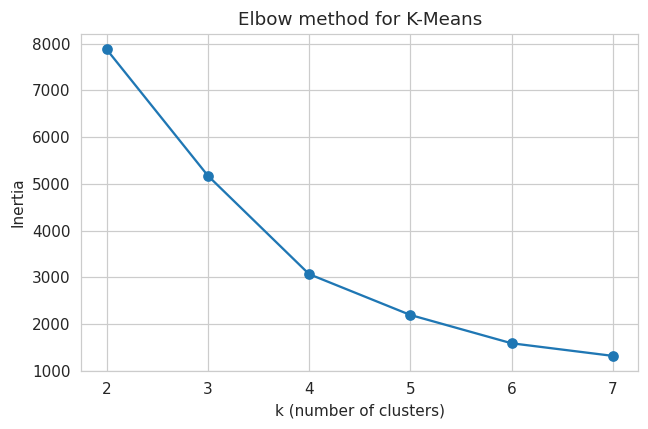

Cluster sizes:
 cluster
0    0.821650
3    0.082520
1    0.069210
2    0.026619
Name: proportion, dtype: float64
Cluster avg distance:
 cluster
0    1.286110
1    1.897337
2    1.222338
3    3.038217
Name: kmeans_distance, dtype: float64
Suspicious clusters flagged: [3, 1, 2]

=== Isolation Forest vs ground truth ===
              precision    recall  f1-score   support

           0      0.965     0.961     0.963       950
           1      0.796     0.814     0.804       177

    accuracy                          0.938      1127
   macro avg      0.880     0.887     0.884      1127
weighted avg      0.938     0.938     0.938      1127


=== K-Means (suspicious clusters) vs ground truth ===
              precision    recall  f1-score   support

           0      0.986     0.961     0.973       950
           1      0.816     0.927     0.868       177

    accuracy                          0.956      1127
   macro avg      0.901     0.944     0.921      1127
weighted avg      0.959    

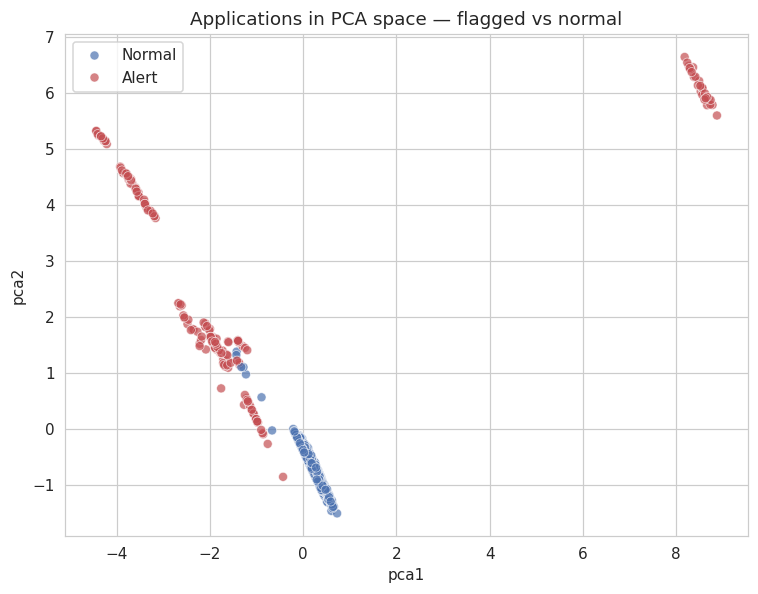

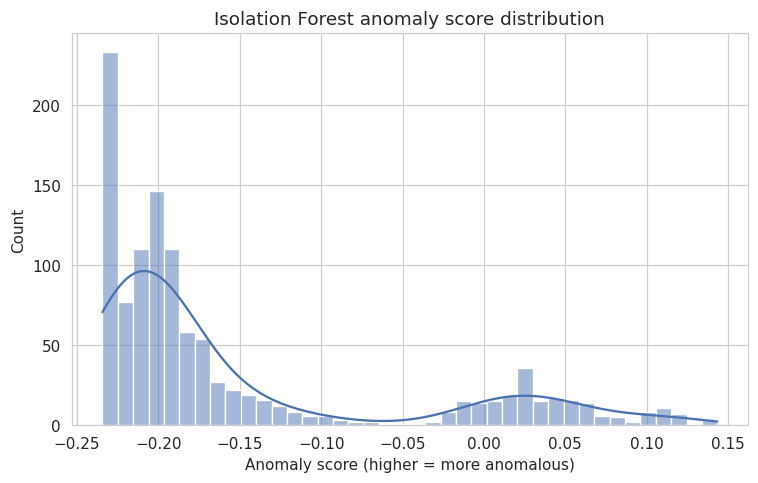

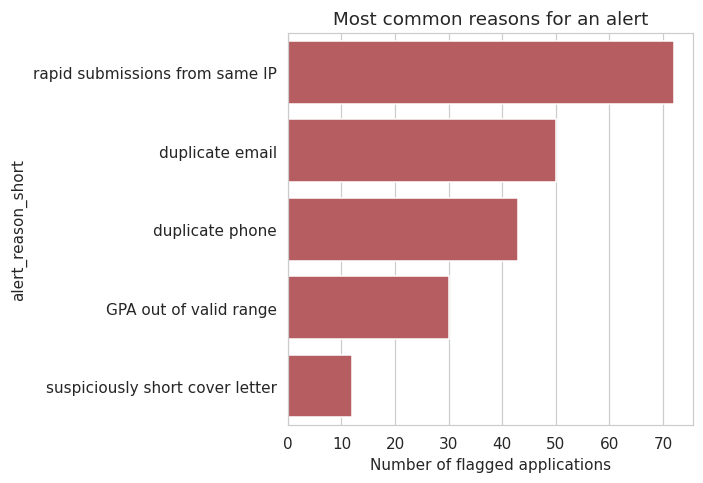

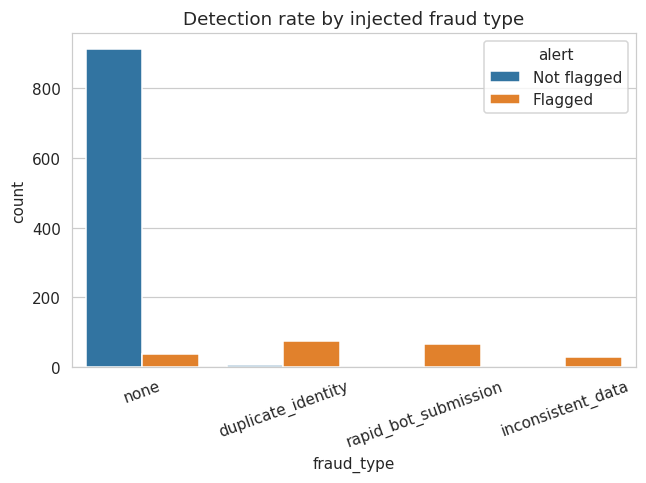


Total applications: 1127
Total alerts raised: 207 (18.4% of applications)
Actual injected fraud: 177 (15.7%)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("applications_features.csv", parse_dates=["submission_time"])

FEATURES = [
    "is_duplicate_email", "is_duplicate_phone", "name_similarity_max",
    "submissions_same_ip", "min_gap_seconds_same_ip", "gpa_invalid",
    "age_invalid", "grad_year_invalid", "short_cover_letter",
    "cover_letter_length",
]

X = df[FEATURES].copy()
# cap the gap feature so a few very-large values don't dominate scaling
X["min_gap_seconds_same_ip"] = X["min_gap_seconds_same_ip"].clip(upper=3600)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- Isolation Forest ----------------
iso = IsolationForest(
    n_estimators=300,
    contamination=0.16,   # ~ matches the expected fraud rate found by the rule checks
    random_state=42,
)
df["iso_pred"] = iso.fit_predict(X_scaled)          # -1 = anomaly, 1 = normal
df["iso_anomaly"] = (df["iso_pred"] == -1).astype(int)
df["iso_score"] = -iso.decision_function(X_scaled)   # higher = more anomalous

# ---------------- K-Means ----------------
# find a reasonable k with the elbow method, then flag small / far-from-centroid clusters
inertias = []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_RANGE), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow method for K-Means")
plt.tight_layout()
plt.savefig("plot_elbow.png")
plt.show()
plt.close()

K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# distance of each point to its own cluster centroid
centroids = kmeans.cluster_centers_
dists = np.linalg.norm(X_scaled - centroids[df["cluster"].values], axis=1)
df["kmeans_distance"] = dists

# a cluster is "suspicious" if it is small (<8% of data) or has an unusually high
# average distance-to-centroid (i.e. a loose, scattered group of outliers)
cluster_sizes = df["cluster"].value_counts(normalize=True)
cluster_avg_dist = df.groupby("cluster")["kmeans_distance"].mean()
suspicious_clusters = cluster_sizes[
    (cluster_sizes < 0.08) | (cluster_avg_dist > cluster_avg_dist.median() * 1.5)
].index.tolist()
df["kmeans_anomaly"] = df["cluster"].isin(suspicious_clusters).astype(int)

print("Cluster sizes:\n", cluster_sizes)
print("Cluster avg distance:\n", cluster_avg_dist)
print("Suspicious clusters flagged:", suspicious_clusters)

# ---------------- Ensemble alert score ----------------
# Combine three independent signals: rule-based checks, Isolation Forest, K-Means.
# An application is ALERTED if at least 2 of the 3 methods agree, or if a hard
# rule (exact duplicate / invalid data) fired on its own.
df["votes"] = df["rule_based_flag"] + df["iso_anomaly"] + df["kmeans_anomaly"]
df["alert"] = ((df["votes"] >= 2) | (df["rule_based_flag"] == 1)).astype(int)

def reason(row):
    reasons = []
    if row["is_duplicate_email"]:
        reasons.append("duplicate email")
    if row["is_duplicate_phone"]:
        reasons.append("duplicate phone")
    if row["submissions_same_ip"] >= 4 and row["min_gap_seconds_same_ip"] < 300:
        reasons.append("rapid submissions from same IP")
    if row["gpa_invalid"]:
        reasons.append("GPA out of valid range")
    if row["age_invalid"]:
        reasons.append("implausible age")
    if row["grad_year_invalid"]:
        reasons.append("implausible graduation year")
    if row["short_cover_letter"]:
        reasons.append("suspiciously short cover letter")
    if row["iso_anomaly"] and not reasons:
        reasons.append("flagged as statistical outlier (Isolation Forest)")
    if row["kmeans_anomaly"] and not reasons:
        reasons.append("belongs to an outlier cluster (K-Means)")
    return "; ".join(reasons) if reasons else "combination of weak signals"

df["alert_reason"] = df.apply(reason, axis=1)

# ---------------- Evaluation against injected ground truth ----------------
print("\n=== Isolation Forest vs ground truth ===")
print(classification_report(df["ground_truth_fraud"], df["iso_anomaly"], digits=3))

print("\n=== K-Means (suspicious clusters) vs ground truth ===")
print(classification_report(df["ground_truth_fraud"], df["kmeans_anomaly"], digits=3))

print("\n=== Ensemble alert vs ground truth ===")
print(classification_report(df["ground_truth_fraud"], df["alert"], digits=3))
cm = confusion_matrix(df["ground_truth_fraud"], df["alert"])
print("Confusion matrix (rows=actual, cols=predicted):\n", cm)

# ---------------- Visualizations ----------------
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=df, x="pca1", y="pca2", hue=df["alert"].map({0: "Normal", 1: "Alert"}),
    palette={"Normal": "#4C72B0", "Alert": "#C44E52"}, alpha=0.7, s=35
)
plt.title("Applications in PCA space — flagged vs normal")
plt.legend(title="")
plt.tight_layout()
plt.savefig("plot_pca_alerts.png")
plt.show()
plt.close()

plt.figure(figsize=(7, 4.5))
sns.histplot(df["iso_score"], bins=40, kde=True, color="#4C72B0")
plt.title("Isolation Forest anomaly score distribution")
plt.xlabel("Anomaly score (higher = more anomalous)")
plt.tight_layout()
plt.savefig("plot_iso_score_dist.png")
plt.show()
plt.close()

plt.figure(figsize=(6.5, 4.5))
df["alert_reason_short"] = df["alert_reason"].apply(lambda r: r.split(";")[0] if r != "combination of weak signals" else r)
top_reasons = df[df["alert"] == 1]["alert_reason_short"].value_counts().head(8)
sns.barplot(x=top_reasons.values, y=top_reasons.index, color="#C44E52")
plt.xlabel("Number of flagged applications")
plt.title("Most common reasons for an alert")
plt.tight_layout()
plt.savefig("plot_alert_reasons.png")
plt.show()
plt.close()

plt.figure(figsize=(6, 4.5))
sns.countplot(data=df, x="fraud_type", hue=df["alert"].map({0: "Not flagged", 1: "Flagged"}),
              order=["none", "duplicate_identity", "rapid_bot_submission", "inconsistent_data"])
plt.xticks(rotation=20)
plt.title("Detection rate by injected fraud type")
plt.tight_layout()
plt.savefig("plot_detection_by_type.png")
plt.show()
plt.close()

# ---------------- Outputs ----------------
alerts = df[df["alert"] == 1].sort_values("iso_score", ascending=False)
alerts[[
    "applicant_id", "name", "email", "ip_address", "submission_time",
    "votes", "alert_reason"
]].to_csv("flagged_applications_alert_log.csv", index=False)

df.to_csv("applications_scored.csv", index=False)

print(f"\nTotal applications: {len(df)}")
print(f"Total alerts raised: {df['alert'].sum()} ({df['alert'].mean()*100:.1f}% of applications)")
print(f"Actual injected fraud: {df['ground_truth_fraud'].sum()} ({df['ground_truth_fraud'].mean()*100:.1f}%)")


## 4. Alert system
An application is escalated as an **alert** when at least two of the three
signals (rule-based checks, Isolation Forest, K-Means) agree, or when a hard
rule fires on its own (exact duplicate email/phone, or clearly invalid data).
Each alert is logged with a plain-language reason so a reviewer doesn't have
to dig through raw feature values.

In [4]:
"""
Simple alert system: scans the scored applications and prints/logs a
human-readable warning for every application that crossed the alert
threshold, so a reviewer can act on it without opening the full dataset.
"""

import pandas as pd

df = pd.read_csv("applications_scored.csv", parse_dates=["submission_time"])
alerts = df[df["alert"] == 1].sort_values("iso_score", ascending=False)

log_lines = []
log_lines.append(f"FRAUD ALERT REPORT — {len(alerts)} suspicious applications out of {len(df)}\n")
log_lines.append("=" * 70)

for _, row in alerts.iterrows():
    risk = "HIGH" if row["votes"] >= 3 else "MEDIUM"
    line = (
        f"[{risk} RISK] {row['applicant_id']} — {row['name']} ({row['email']})\n"
        f"    Submitted: {row['submission_time']}   IP: {row['ip_address']}\n"
        f"    Reason(s): {row['alert_reason']}\n"
    )
    log_lines.append(line)

report = "\n".join(log_lines)
with open("alert_report.txt", "w") as f:
    f.write(report)

print(report[:2000])
print(f"\n... full report written to alert_report.txt ({len(alerts)} entries)")


FRAUD ALERT REPORT — 207 suspicious applications out of 1127

[HIGH RISK] INC025 — Zohaib Iqbal (zohaib.iqbal330@hotmail.com)
    Submitted: 2026-08-15 21:27:23.432157   IP: 1.38.128.182
    Reason(s): GPA out of valid range; implausible age; implausible graduation year

[HIGH RISK] INC006 — Ali Khan (ali.khan266@yahoo.com)
    Submitted: 2026-09-10 22:42:42.050849   IP: 137.234.102.198
    Reason(s): GPA out of valid range; implausible age; implausible graduation year

[HIGH RISK] INC011 — Noor Soomro (noor.soomro390@gmail.com)
    Submitted: 2026-08-21 08:45:00.395646   IP: 220.51.181.93
    Reason(s): GPA out of valid range; implausible age; implausible graduation year

[HIGH RISK] INC015 — Momina Ahmed (momina.ahmed553@gmail.com)
    Submitted: 2026-08-06 01:19:42.571374   IP: 44.80.51.4
    Reason(s): GPA out of valid range; implausible age; implausible graduation year

[HIGH RISK] INC028 — Uzma Malik (uzma.malik238@hotmail.com)
    Submitted: 2026-08-16 20:29:48.496449   IP: 211.

## 5. Summary

- The ensemble alert system flagged **207 of 1,127 applications (18.4%)**, against **177 (15.7%)** injected fraud cases.
- Against the ground truth it reached **96% recall and 82% precision** for the fraud class, i.e. it caught 170 of the 177 injected fraud cases, at the cost of 37 genuine applications flagged for manual review.
- Rapid submissions from the same IP and duplicate email/phone were the most common reasons for an alert, followed by out-of-range GPA and very short cover letters.
- K-Means clustering on its own performed close to Isolation Forest (F1 ≈ 0.87 vs 0.80), and combining both improved F1 to 0.885 while keeping recall high — which matters more than precision here, since a missed fraudulent entry is more costly than one extra manual review.
- This is a detection layer, not a rejection layer: every alert is meant to be manually reviewed rather than auto-rejected, since a few genuine applicants can still legitimately share an IP (e.g. a university lab) or submit close together.
